# SpeciesNet demo notebook by EcoCommons and Atlas of Living Australia (ALA)

Author: Renuka Sharma

Editor: Xiang Zhao, Jenna Wraith

Reviewer: ALA (Martin Westgate)

## Pre-requisites
Basic understanding of Python programming language. You can refer to this book https://wesmckinney.com/book/ 

## Environment setup
This is the hardest part.
We are choosing Conda for environment setup. 

The env is used to handle Python + ML libraries cleanly.
Please refer to the link for more resources on getting strated with a conda environment.

📘 https://docs.conda.io/projects/conda/en/latest/user-guide/getting-started.html

In this notebook, we are giving you the steps to execute while using VS Code as an editor.

In [1]:
# Setting up the env for running the notebook: You do not need to run  this cell every time, just the first time you are setting up the env.
# Step 1: In VS code, press Ctrl+Shift+P to enter the selection mode. 
# Step 2: Go to "Python: Select interpreter" -> Create Virtual Environment -> Conda (recommended) to create a conda env in teh current workspace.
# Step 3: Select Python version: Python 3.11
# Step 4: At the bottom-right corner, you will see: The follwoing env is selected: ~/Documents/EcoCommons/EC_notebook/.conda
# You are good to go and start using the Conda env.

# The commands below  will install the packages needed to run the code in this notebook
! pip install pandas # Used for handling Python data frames
! pip install galah-python # We will download the data from ALA website using their galah package which is also available in R.
! pip install requests # For handling the URLs and downloading them
! pip install speciesnet # To dowmload the ML model we are using for species identification



After you have successfully setup the environment, which you have to do only once, thr first time of running this notebook, you are ready to roll with teh code below.
We will first start with the downloading of data from ALA.

## About Galah package from ALA
We are downloading the data from ALA website using their galah package https://galah.ala.org.au/ which is available in both R and Python programming language. The source code of Python based galah package can be found at http://github.com/AtlasOfLivingAustralia/galah-python.

### Imports and utillity functions for data downloading

In [2]:
# Importing the necessary Python packages
# When you first run this cell, VS code might install ipykernel, if not installed already
import os
from pathlib import Path
import pandas as pd
import galah
from pathlib import Path
import requests
import shutil
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

def empty_directory(directory: Path):
    """
    Deletes all files and subdirectories inside `directory`,
    but does not delete the directory itself.
    """
    if not directory.exists():
        directory.mkdir(parents=True)
        return

    for item in directory.iterdir():
        if item.is_file() or item.is_symlink():
            item.unlink()
        elif item.is_dir():
            shutil.rmtree(item)

In [23]:
# Config galah with region and email + define directory
# galah.galah_config(atlas="Australia")
galah.galah_config(email="renuka.sharma@qcif.edu.au") # mandatory to provide an email

# 1) Get metadata only (no downloading yet)
media_df = galah.atlas_media(
    # taxa="Tachyglossus aculeatus", # <-- Please feel free to change the scientific name to the species you want to download
    # taxa="Casuarius casuarius", # <-- Please feel free to change the scientific name to the species you want to download
    taxa = ['Felis catus', 'Sus scrofa'],     
    # taxa = ["Vombatus ursinus", "Colluricincla harmonica" ],
    # filters=["year=2024", "cl22=Queensland"],
    filters=["cl22=Queensland"],
    # filters = ["year=2024"],
    multimedia="images",
    collect=False   # <-- critical: metadata only
)

In [5]:
print("Columns in our data frame:",media_df.columns)
print("Unique data resources for our dataset are:", media_df['dataResourceName'].unique())
print("Unique data resources for our dataset are:", media_df['scientificName'].unique())

Columns in our data frame: Index(['decimalLatitude', 'decimalLongitude', 'eventDate', 'scientificName',
       'recordID', 'dataResourceName', 'occurrenceStatus', 'multimedia',
       'images', 'videos', 'sounds', 'creator', 'license', 'mimetype', 'width',
       'height', 'imageUrl'],
      dtype='object')
Unique data resources for our dataset are: ['iNaturalist Australia'
 "Camera trap surveys in Queensland's Wet Tropics 2022-2023"
 'Earth Guardians Weekly Feed' 'ALA species sightings and OzAtlas'
 'BowerBird' 'Museums Victoria provider for OZCAM'
 'Encyclopedia of Life Images - Flickr Group']
Unique data resources for our dataset are: ['Casuarius casuarius' 'Vombatus ursinus'
 'Casuarius casuarius johnsonii (northern population)']


In [24]:
# values_to_keep = ['iNaturalist Australia', 'Echidna-CSI']
# values_to_keep = ['iNaturalist Australia']
values_to_keep = ["Camera trap surveys in Queensland's Wet Tropics 2022-2023", "Monitoring many landscapes in VIC-NSW border to assess impacts of 2019-20 gigafires on wildlife diel activity", "Wombat burrows are hotspots for small vertebrates in a landscape subject to gigafire"]
# target_species = ['Tachyglossus aculeatus', 'Casuarius casuarius']
target_species = ['Felis catus', 'Sus scrofa']

filtered_df = media_df[
    media_df["dataResourceName"].isin(values_to_keep) &
    media_df["scientificName"].isin(target_species)
]
# filtered_df = media_df[
#     media_df["dataResourceName"] == values_to_keep &
#     (media_df["scientificName"] == 'Tachyglossus aculeatus')
# ]
# print(filtered_df)

In [25]:
# Pick just N images (random or head). We are sampling only N images from the downloaded set.
N_IMAGES = 6 # Number of images you want to download in your folder
subset_df = filtered_df.sample(min(N_IMAGES, len(media_df)))  # random sample, OR the command belows
# subset_df = subset_df.head(N_IMAGES)                  # if you want to take the first N samples
print(f"Subset data frame after taking only {N_IMAGES}:\n", subset_df)

Subset data frame after taking only 6:
       decimalLatitude  decimalLongitude             eventDate scientificName  \
2432       -17.318559        145.809862  2023-01-17T00:00:00Z     Sus scrofa   
3022       -17.368015        145.711147  2023-02-26T00:00:00Z    Felis catus   
4408       -17.343730        145.748843  2023-01-01T00:00:00Z    Felis catus   
308        -17.104674        145.612914  2022-10-08T00:00:00Z     Sus scrofa   
1429       -16.234159        145.449934  2022-11-07T00:00:00Z     Sus scrofa   
3896       -17.367438        145.753085  2022-12-24T00:00:00Z    Felis catus   

                                  recordID  ... license    mimetype width  \
2432  b9c92e30-5551-4724-943c-9865af37adcf  ...    None  image/jpeg  2048   
3022  7d604484-46fe-40bd-ae80-0803c46d77e1  ...    None  image/jpeg  6144   
4408  4e003c6c-06f6-4514-a7b1-5182ff057306  ...    None  image/jpeg  2048   
308   f93b56ab-eafe-4508-a13f-b1dc6a3501a5  ...    None  image/jpeg  6144   
1429  eaaa2e9c

In [26]:
# Empty out th directory before downloading new items to it
# Setting up the configuration for downloading the dataset from ALA website into the folder "EC images".
image_folder = Path("EC_images") # Define the folder where the downloaded images will be saved
# image_folder.mkdir(exist_ok=True) # We will create the folder if it does not exist
empty_directory(image_folder) # <-- !! Be careful while executing this command. It will delete everything in the image_folder

In [27]:
# Download only chosen records in the image_folder
for i, row in subset_df.iterrows():
    url = row["imageUrl"]   # this column stores the image URL

    filename = image_folder / f"{i}.jpg"

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        filename.write_bytes(r.content)
    except Exception as e:
        print(f"Failed to download {url}: {e}")

Now your data is ready to be processed through SpeciesNet ML model! :)

### Display images here

In [28]:
# Make sure that your images have been downloaded
image_dir = Path(image_folder)
image_paths = list(image_dir.glob("*"))

print(f"Found {len(image_paths)} files")
image_paths[:6]

Found 6 files


[PosixPath('EC_images/3896.jpg'),
 PosixPath('EC_images/3022.jpg'),
 PosixPath('EC_images/4408.jpg'),
 PosixPath('EC_images/308.jpg'),
 PosixPath('EC_images/1429.jpg'),
 PosixPath('EC_images/2432.jpg')]

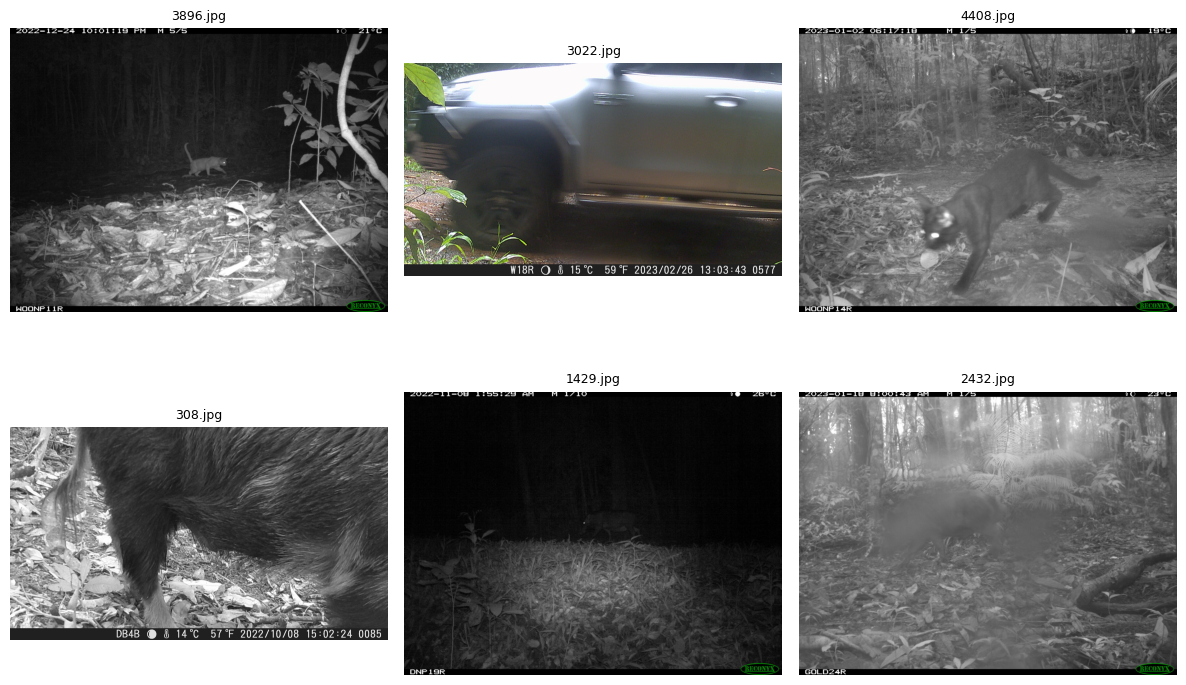

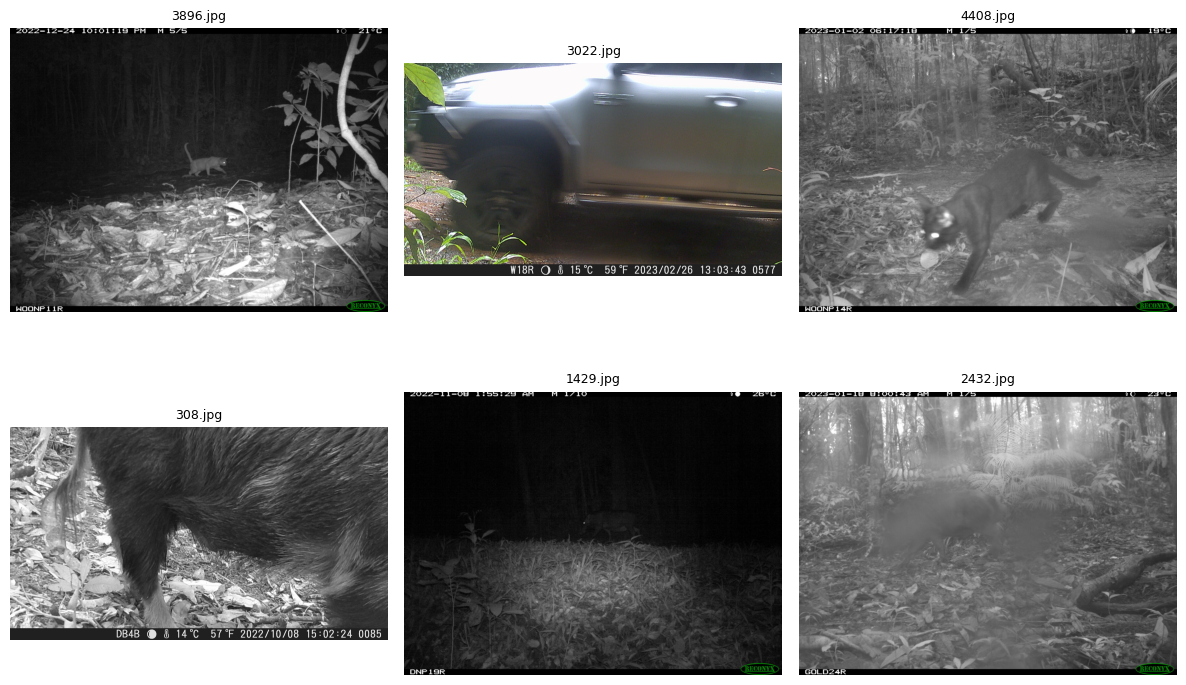

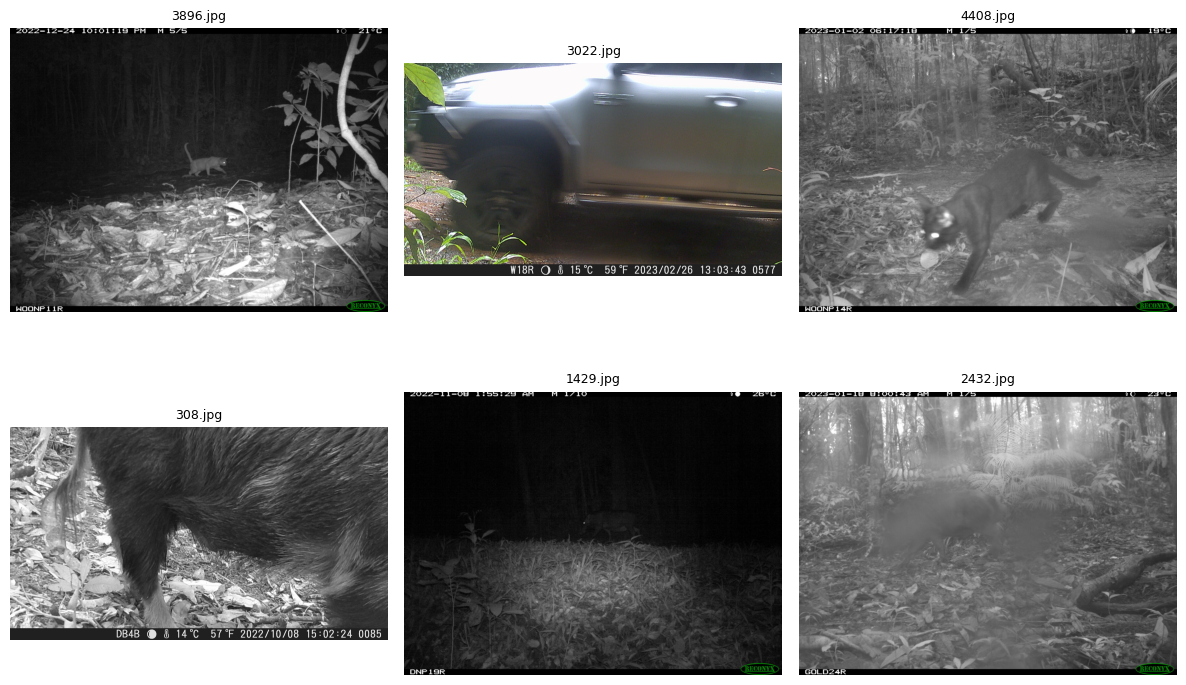

In [31]:
# plt.close("all")
%matplotlib inline
image_dir = Path(image_folder)

# Get first 6 image files
image_paths = list(image_dir.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, img_path in zip(axes.flatten(), image_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## About SpeciesNet
This is a simple notebook that runs the SpeciesNet model which is an ensemble of AI models for classifying wildlife in camera trap images.
The species classifier (SpeciesNet) was trained at Google using a large dataset of camera trap images. It is designed to classify images into one of more than 2000 labels, covering diverse animal species, higher-level taxa (like "mammalia" or "felidae"), and non-animal classes ("blank", "vehicle"). 
SpeciesNet has been trained on a geographically diverse dataset of over 65M images, including curated images from the Wildlife Insights user community, as well as images from publicly-available repositories.

Official SpeciesNet GitHub repo can be found at https://github.com/google/cameratrapai

### Imports and utility functions for running SpeciesNet

In [32]:
from IPython.display import display
from IPython.display import JSON

from speciesnet import DEFAULT_MODEL
from speciesnet import draw_bboxes
from speciesnet import load_rgb_image
from speciesnet import SpeciesNet
from speciesnet import SUPPORTED_MODELS
import warnings
warnings.filterwarnings('ignore')


def print_predictions(predictions_dict: dict) -> None:
    print("Predictions:")
    for prediction in predictions_dict["predictions"]:
        print(prediction["filepath"], "=>", prediction["prediction"])

### Choose model variation
In SpeciesNet, **geofencing** is a post-classification filtering step that uses geographic information (country and optionally sub-region) to remove biologically implausible species predictions.


In [33]:
warnings.filterwarnings('ignore')
print("Default SpeciesNet model:", DEFAULT_MODEL)
print("Supported SpeciesNet models:", SUPPORTED_MODELS)
model = SpeciesNet(DEFAULT_MODEL) # geofence is set to True by default
# model = SpeciesNet(DEFAULT_MODEL, geofence=False) # You can disable geofencing, if you like. This will disable your prediction restructions to a country/region you have chosen.

Default SpeciesNet model: kaggle:google/speciesnet/pyTorch/v4.0.1a
Supported SpeciesNet models: ['kaggle:google/speciesnet/pyTorch/v4.0.1a', 'kaggle:google/speciesnet/pyTorch/v4.0.1b']


### Run SpeciesNet

Switch to any of the commented lines if you want to run the model on a different input format.

You can provide folder names for model prediction as follows...

In [34]:
predictions_dict = model.predict(folders=[image_folder])

print_predictions(predictions_dict)
# display(JSON(predictions_dict)) # Uncomment if you want to see verbose

Predictions:
EC_images/1429.jpg => d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar
EC_images/2432.jpg => d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar
EC_images/3022.jpg => e2895ed5-780b-48f6-8a11-9e27cb594511;;;;;;vehicle
EC_images/308.jpg => f2d233e3-80e3-433d-9687-e29ecc7a467a;mammalia;;;;;mammal
EC_images/3896.jpg => 9212982e-8a58-4775-a6ac-e9a43110d8f5;mammalia;carnivora;felidae;felis;catus;domestic cat
EC_images/4408.jpg => 9212982e-8a58-4775-a6ac-e9a43110d8f5;mammalia;carnivora;felidae;felis;catus;domestic cat


An example prediction is as follows: <br>
1b30ddf8-22fb-40ff-9df6-6a8a0b6ccaa1;mammalia;monotremata;tachyglossidae;tachyglossus;aculeatus;short-beaked echidna <br>
It should be read as follows: <br>
UUID;Class;Order;Family;Genus;Species-epithet;common-name

You can also give the file paths instead as follows...

In [35]:
image_paths = sorted(
    p for p in image_folder.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
)

# predictions_dict = model.predict(filepaths=[
#     "EC_images/453.jpg", # <-- You can change the name of the file here
#     # "EC_images/506.jpg", # <-- You can also add more image links here
# ])

predictions_dict = model.predict(filepaths=[
    image_paths[3],
    image_paths[5]
])

print_predictions(predictions_dict)
# display(JSON(predictions_dict))

Predictions:
EC_images/308.jpg => f2d233e3-80e3-433d-9687-e29ecc7a467a;mammalia;;;;;mammal
EC_images/4408.jpg => 9212982e-8a58-4775-a6ac-e9a43110d8f5;mammalia;carnivora;felidae;felis;catus;domestic cat


### Display detections (overlaying on the input image)

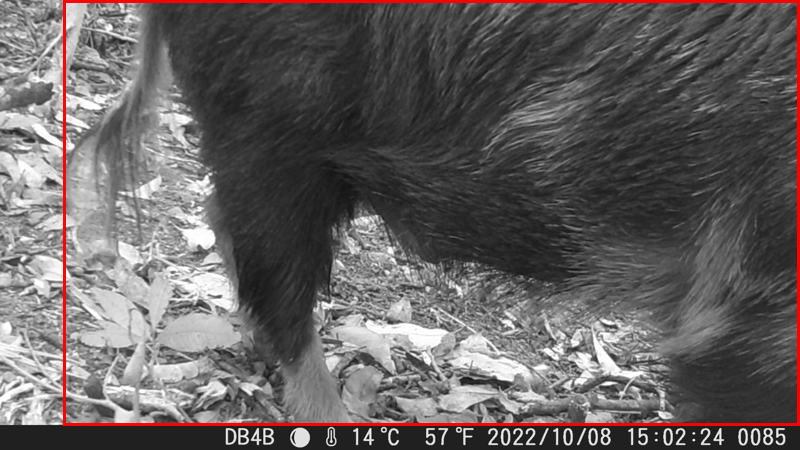

In [36]:
first_prediction_item = predictions_dict["predictions"][0]
img = load_rgb_image(first_prediction_item["filepath"])
detections = first_prediction_item["detections"]
img.thumbnail(size=(800, 800))
draw_bboxes(img, detections)

### SpecisNet is an ensemble model, consisting of a detector and a classifier
You can run the classifier and detector separately as follows.

### Run only the classifier

In [37]:
predictions_dict = model.classify(
    filepaths=[
    image_paths[3],
    image_paths[5],
])
display(JSON(predictions_dict))

<IPython.core.display.JSON object>

### Run only the detector

In [38]:
predictions_dict = model.detect(
    filepaths=[
    image_paths[3],
    image_paths[5],
])
display(JSON(predictions_dict))

<IPython.core.display.JSON object>

### See geofencing in action


SpeciesNet uses ISO 3166-1 alpha-3 country codes (3-letter codes) for geofencing. <br>
Examples (common ones) <br>
Country	Code <br>
Australia	AUS <br>
New Zealand	NZL <br>
United States	USA <br>
Canada	CAN <br>
Mexico	MEX <br>
United Kingdom	GBR <br>
Germany	DEU <br>
France	FRA <br>
Spain	ESP <br>
Italy	ITA <br>
Brazil	BRA <br>
Argentina	ARG <br>
South Africa	ZAF <br>
Kenya	KEN <br>
India	IND <br>
China	CHN <br>
Japan	JPN <br>

These are case-insensitive, but uppercase is standard.

In [39]:
predictions_dict = model.predict(
    instances_dict={
        "instances": [
            {
                "filepath": str(image_paths[0]),
                "country": "AUS",
            },
        ]
    }
)
print_predictions(predictions_dict)
# display(JSON(pr/edictions_dict))

Predictions:
EC_images/1429.jpg => d372cda5-a8ca-4b7b-97ed-4e4fab9c9b4b;mammalia;cetartiodactyla;suidae;sus;scrofa;wild boar


### Disable geofencing

In [ ]:
# Geofencing the enabled by default, you can disble it if needed, by uncommenting the code below
# model = SpeciesNet(DEFAULT_MODEL, geofence=False)

In [40]:
predictions_dict = model.predict(
    instances_dict={
        "instances": [
            {
                "filepath": str(image_paths[0]),
                "country": "AUS",
            },
        ]
    }
)
display(JSON(predictions_dict))

<IPython.core.display.JSON object>

#### Copyright information from SpeciesNet

Copyright 2024 Google LLC

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.